# 0? Text Intelligence & Review Analytics

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

## 1. Data Loading

### 1.1 Read review_analysis.db database

In [2]:
# Connect to the database
conn = sqlite3.connect("../data/reviews_analysis.db")

# Read all table in the database
hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

In [3]:
# Print our table name
tables = hotels_df['name'].tolist()
tables

['reviews', 'authors', 'hotels']

### Save dataset as dictionary

In [4]:
# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

In [5]:
# Print dictionary keys to ensure the tables are in
dataset.keys()

dict_keys(['reviews', 'authors', 'hotels'])

In [6]:
# Print every column and data type for each table
for table in dataset.keys():
    print(f'\nTable name:   {table}')
    print(f'{dataset[table].dtypes}')


Table name:   reviews
title                       object
text                        object
date_stayed                 object
hotel_id                    object
num_helpful_votes            int64
review_date                 object
review_id                   object
via_mobile                   int64
service_rating             float64
cleanliness_rating         float64
overall_rating             float64
value_rating               float64
location_rating            float64
sleep_quality_rating       float64
rooms_rating               float64
check_in_service_rating    float64
business_service_rating    float64
author_id                   object
dtype: object

Table name:   authors
id                    object
username              object
num_cities           float64
num_helpful_votes    float64
num_reviews          float64
num_type_reviews     float64
location              object
alias                 object
dtype: object

Table name:   hotels
hotel_id                        object
num

### Converting dates to datetime

In [7]:
# Convert 'date_stayed' to datetime
dataset['reviews']['date_stayed'] = pd.to_datetime(
    dataset['reviews']['date_stayed'],
    errors='coerce'
)

# Convert 'review_date' to datetime
dataset['reviews']['review_date'] = pd.to_datetime(
    dataset['reviews']['review_date'],
    errors='coerce'
)

In [8]:
# Show
dataset['reviews']['date_stayed'].isna().sum()

0

In [9]:
# Remove NaN entry from the reviews if the date_stayed is empty
dataset['reviews'].dropna(subset='date_stayed', inplace=True)

In [10]:
# Print
print(f"length of data after dropping: {len(dataset['reviews'])}")

length of data after dropping: 80000


## 2. Text Data Exploration

In [11]:
reviews_df = dataset['reviews']
reviews_df.head()

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E


In [12]:
reviews_df[reviews_df['text'] == ""]

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id


There is no empty review

In [13]:
reviews_df["review"] = reviews_df["title"] + " " + reviews_df["text"]
reviews_df

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,review
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,“Daaaaaa Bears!” I recently stayed at W Chicag...
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,“Would go back in a heartbeat- Location Locati...
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75,"“Clean, Friendly, Affordable Alternative to Do..."
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00,"“Atrium pool, location and basic amenities wer..."
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E,“Very Good but Nothing Spectacular” Stayed her...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,“Oops. Not the best choice for me.”,"The W Boston should have been better for me, b...",2009-12-01,1486034,0,2009-12-07,50826156,0,4.0,2.0,3.0,2.0,4.0,NaN,3.0,NaN,NaN,309A277A5D221634DA28090144520A10,“Oops. Not the best choice for me.” The W Bost...
79996,“My favorite hotel in Seattle”,The Alexis is the best. The service is always ...,2012-01-01,112412,0,2012-01-30,123858080,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,8C7A26020CD00F6C88B7A2537AB0F3BE,“My favorite hotel in Seattle” The Alexis is t...
79997,“Good but to hot”,This hotel needs aircon the rooms are to warm ...,2011-09-01,115644,1,2011-10-06,118987846,0,5.0,5.0,4.0,3.0,5.0,3.0,4.0,NaN,NaN,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,“Good but to hot” This hotel needs aircon the ...
79998,“Everything you would expect from a 4 star pro...,I had a late evening flight into Houstons Hobb...,2011-05-01,1549134,0,2011-05-26,109895397,0,5.0,5.0,5.0,4.0,5.0,5.0,4.0,NaN,NaN,220F304A84F86A2E5AF856F270C775D5,“Everything you would expect from a 4 star pro...


### Handcrafted features

In [14]:
reviews_df["review"].duplicated().sum()

1

In [15]:
print(reviews_df[reviews_df["review"].duplicated(keep=False)])


                   title                                               text  \
36884  “Terrific hotel!”  The rooms were huge and very comfortable, and ...   
73513  “Terrific hotel!”  The rooms were huge and very comfortable, and ...   

      date_stayed hotel_id  num_helpful_votes review_date  review_id  \
36884  2012-07-01   109367                  0  2012-07-12  134201529   
73513  2012-07-01   109370                  0  2012-07-12  134201729   

       via_mobile  service_rating  cleanliness_rating  overall_rating  \
36884           0             5.0                 5.0             5.0   
73513           0             5.0                 5.0             5.0   

       value_rating  location_rating  sleep_quality_rating  rooms_rating  \
36884           5.0              4.0                   5.0           5.0   
73513           5.0              4.0                   5.0           5.0   

       check_in_service_rating  business_service_rating  \
36884                      NaN       

The content is identical but the hotel_id is different, this is probably a review given by a bot or potentially fake reviews, but we'll keep it.

### Feature 1 - Review Length

In [16]:
reviews_df['review_length'] = reviews_df['review'].apply(lambda x: len(x.split()))
reviews_df['review_length'].describe()

count    80000.000000
mean       156.833538
std        131.690529
min          2.000000
25%         74.000000
50%        121.000000
75%        196.000000
max       4240.000000
Name: review_length, dtype: float64

In [17]:
reviews_df[reviews_df['review_length'] > 2000]

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,review,review_length
39903,"“New Hotel, Some Good things, Some Areas Need ...","I just stayed at the new Omni Dallas, located ...",2011-11-01,2192761,6,2011-11-18,120767833,0,3.0,1.0,3.0,4.0,5.0,5.0,3.0,NaN,NaN,F49E82836E824D73772CF4C1F681F1E3,"“New Hotel, Some Good things, Some Areas Need ...",3186
50959,“Will the nightmare ever end...”,This was hands down the worst ever experience ...,2012-09-01,208452,6,2012-10-02,141808348,0,1.0,3.0,1.0,1.0,3.0,1.0,1.0,NaN,NaN,740FD131340886563E5503CCF2CDF8E8,“Will the nightmare ever end...” This was hand...,4240
52809,“Great deal and customer service made this an ...,"From the time of check-in until check out, the...",2012-01-01,1479845,3,2012-02-27,125271060,0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,NaN,NaN,87576E9615B5A13F32929624481E6AD0,“Great deal and customer service made this an ...,2383
60491,“Worthy of Consideration When Planning a Stay ...,We just returned from a two night stay at Hote...,2011-11-01,124048,7,2011-11-07,120255462,0,4.0,2.0,4.0,4.0,5.0,5.0,5.0,NaN,NaN,E3B93CF3EB31E17B9097EF741B0C9197,“Worthy of Consideration When Planning a Stay ...,2080


In [18]:
reviews_df[reviews_df['review_length'] == 2]

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,review,review_length
173,“ビバリーヒルズの端”,ビバリーヒルズ中心街（ロデオドライブなど）から南へ約２キロメートルくらいのところにあるので、...,2009-11-01,76061,0,2009-12-19,51510534,0,4.0,3.0,3.0,3.0,3.0,NaN,4.0,NaN,NaN,82BE52AF244B51BDE1595E525CA48C4F,“ビバリーヒルズの端” ビバリーヒルズ中心街（ロデオドライブなど）から南へ約２キロメートルく...,2
189,“車なしの旅行者向け”,路面電車のオズボーン駅から徒歩３分。すぐ隣にはラディソンがあって競合しているので、割とリーズ...,2011-01-01,73840,0,2011-01-07,92141237,0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,NaN,92DD451F03811BFAB00415AD30EBD667,“車なしの旅行者向け” 路面電車のオズボーン駅から徒歩３分。すぐ隣にはラディソンがあって競合...,2
198,“長時間のストップオーバーに”,ストップオーバーの為利用しました。空港とホテル間のシャトルが便利で到着後スムーズに移動出来助...,2011-09-01,84182,0,2011-09-23,118510489,0,4.0,3.0,3.0,3.0,4.0,3.0,3.0,NaN,NaN,857B9FCAE87EAB0D4187362C471469E6,“長時間のストップオーバーに” ストップオーバーの為利用しました。空港とホテル間のシャトルが...,2
3172,“空港利用者に便利”,２４時間空港への無料送迎バスがあるので、空港を利用する場合には便利です。ホテルは少々古くなっ...,2008-07-01,77923,0,2008-08-16,19015869,0,4.0,4.0,3.0,4.0,4.0,NaN,3.0,4.0,4.0,DBA6A3E830C7EC9A2ABD4100841FA6B2,“空港利用者に便利” ２４時間空港への無料送迎バスがあるので、空港を利用する場合には便利です...,2
3296,“ゲストサービスに満足。ファミリーに最適！”,家族（4歳と8歳の子ども連れ）で2泊しました。小麦・卵などのアレルギーを持つ息子を連れての旅...,2010-09-01,77917,2,2010-10-14,83438279,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,6ECC6B459DE476CB57861A5790132ACE,“ゲストサービスに満足。ファミリーに最適！” 家族（4歳と8歳の子ども連れ）で2泊しました。...,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76915,“便利なところにあります。”,今年の9月に3泊しました。地下鉄駅の出口がすぐのところにありユニバーサルスタジオにも地下鉄で...,2012-09-01,77798,0,2012-10-05,142103547,0,4.0,4.0,3.0,3.0,5.0,4.0,4.0,NaN,NaN,118F2222EE4A2E3F8A7883E617F17779,“便利なところにあります。” 今年の9月に3泊しました。地下鉄駅の出口がすぐのところにありユ...,2
77219,“日本語が通じる”,部屋はとても綺麗でしたがトイレのウォッシュレットが壊れていたので使えませんでした。部屋には冷...,2009-03-01,223046,0,2009-03-28,27003336,0,4.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,086E549FE8BACEBA773E313FF261DD76,“日本語が通じる” 部屋はとても綺麗でしたがトイレのウォッシュレットが壊れていたので使えませ...,2
79106,“立地場所は良いと思います”,ミシガンアベニューに近いので、買い物や食事には便利です。ただ、ホテル内のレストランが１つしか...,2012-11-01,111507,0,2012-11-23,146045895,0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,NaN,NaN,6FE3647DD0C3623A9732511F19105349,“立地場所は良いと思います” ミシガンアベニューに近いので、買い物や食事には便利です。ただ、...,2
79193,“レンタカーに便利”,空港に深夜着のため、空港から近く、翌朝すぐレンタカーを借りられるホテルを探しました。どうやら...,2012-04-01,73821,0,2012-05-10,129696595,0,4.0,5.0,5.0,5.0,4.0,5.0,5.0,NaN,NaN,22A84E67E64C8ABE4CE3EC4841BCDFBE,“レンタカーに便利” 空港に深夜着のため、空港から近く、翌朝すぐレンタカーを借りられるホテル...,2


### Translate foreign language to english

In [19]:
%pip install langdetect


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

reviews_df["language"] = reviews_df["review"].apply(detect_lang)

In [21]:
reviews_df["language"].value_counts()

language
en       74619
fr        1264
it        1210
de        1175
es         987
ja         322
pt         258
nl          76
sv          37
no          17
ru          12
da          11
tr           3
zh-tw        3
pl           2
th           1
zh-cn        1
el           1
so           1
Name: count, dtype: int64

We have 74620 english language, still a big amount of data, so we'll filter the reviews_df to get only the english review.

In [22]:
reviews_df = reviews_df[reviews_df['language'] == 'en']

reviews_df['review_length'].describe()

count    74619.000000
mean       160.208057
std        133.780662
min          5.000000
25%         76.000000
50%        124.000000
75%        200.000000
max       4240.000000
Name: review_length, dtype: float64

In [23]:
reviews_df['review_length'].value_counts()

review_length
83      466
56      446
77      444
76      443
95      437
       ... 
1041      1
917       1
3186      1
740       1
856       1
Name: count, Length: 1033, dtype: int64

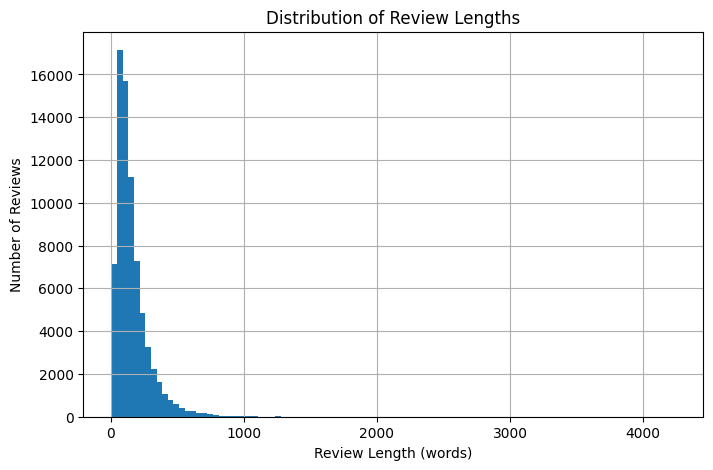

In [24]:
plt.figure(figsize=(8,5))

plt.hist(reviews_df["review_length"], bins=100)

plt.grid()
plt.xlabel("Review Length (words)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

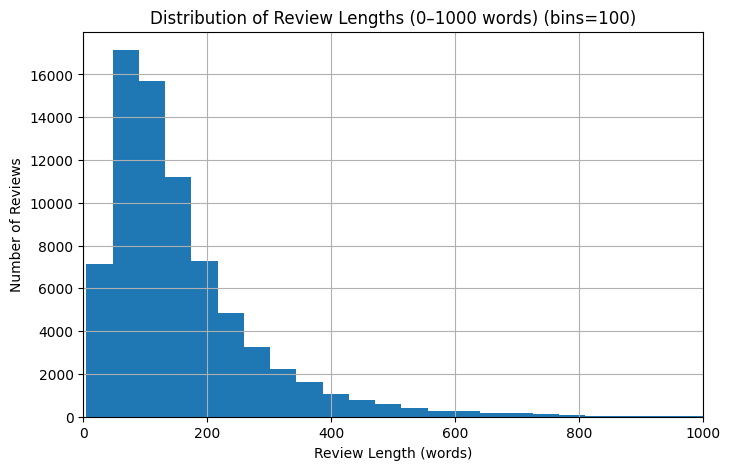

In [25]:
plt.figure(figsize=(8,5))

plt.hist(reviews_df["review_length"], bins=100)

plt.xlim(0, 1000)

plt.grid()
plt.xlabel("Review Length (words)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths (0–1000 words) (bins=100)")

plt.show()

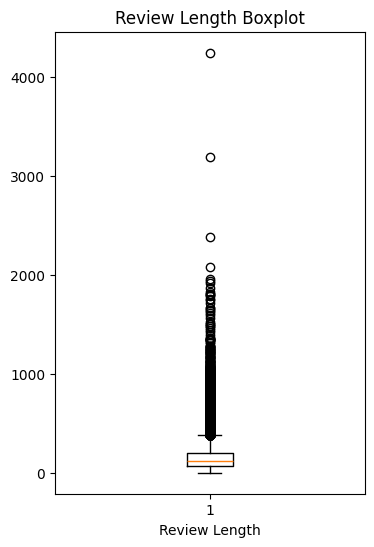

In [26]:
plt.figure(figsize=(4,6))

plt.boxplot(reviews_df["review_length"])

plt.xlabel("Review Length")
plt.title("Review Length Boxplot")

plt.show()

There are many outliers, but for reviews dataset, this is normal and expected. We cannot remove this as longer text naturally brings more detailed stories, only that the length is seen as outliers.

Because we know the skewness of the plot is extreme, we can try the log transformed distribution with the review length to surpress the extreme length cases.

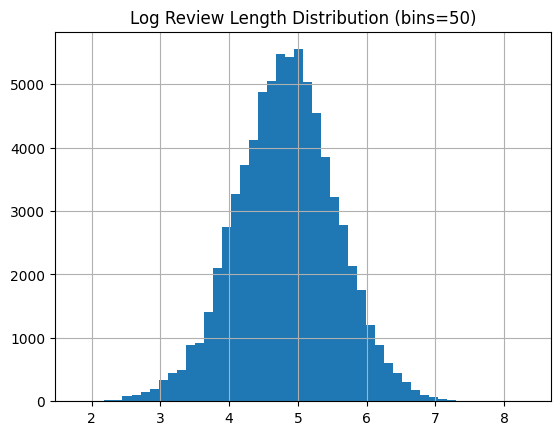

In [27]:
plt.hist(np.log1p(reviews_df["review_length"]), bins=50)
plt.grid()
plt.title("Log Review Length Distribution (bins=50)")
plt.show()

Now that it's shaped like a bell curve, we can tell that this dataset is still acceptable and healthy. The dataset is not dominated by the extremely long or extremely short reviews.

In [28]:
reviews_df["review"].sample(10)

6856     “1960's Los Angeles” This place is great. It's...
23210    “DO NOT STAY HERE. Many other hotels in the ar...
79418    “Best value, clean, gret location but small ro...
53817    “Everyone with a negative comment. You are wro...
74525    “such a good hotel!” such a good hotel located...
16196    “An Exemplary Hotel in Phili.” Every member of...
54823    “Excellent Location & Value for Money” Stayed ...
51381    “New Year @ The Millenium Hilton” Stayed @ the...
45012    “Was a pleasure to stay here!” The history and...
8551     “Just an OK hotel close to LAX airport” This h...
Name: review, dtype: object

After running the code multiple times, the sample looks correct.

## 3. Text Preprocessing

Steps:
1. Lowercase
2. Remove punctuation
3. Remove stopwords
4. Lemmatization

In [29]:
%pip install -q nltk


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()                         # 1. Lowercase
    text = re.sub(r"[^\w\s]", "", text)       # 2. Remove punctuation
    words = text.split()

    words = [w for w in words if w not in stop_words]       # 3. Remove Stopwords

    words = [lemmatizer.lemmatize(w) for w in words]        # 4. Lemmatization

    return " ".join(words)

reviews_df["clean_review"] = reviews_df["review"].apply(preprocess)

/var/folders/9_/fy5p9d_52f9d3dxp8df05zlc0000gn/T/ipykernel_12057/24863942.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_df["clean_review"] = reviews_df["review"].apply(preprocess)


In [31]:
sample_reviews = reviews_df[['review', 'clean_review']].sample(5)

for i, row in sample_reviews.iterrows():
    print("=" * 50)
    print("Original:", row["review"])
    print("\nCleaned:", row["clean_review"])
    print("=" * 50)

Original: “Great little boutique hotel” I've been coming here for over 15 years and the newest renovations are great. Rooms are spacious and nicely upgraded, staff is exceptionally helpful, good little restaurant on premises, a hip little pool area, easy in and out valet, and the best location in Los Angeles with an easy commute to downtown, westside, Santa Monica, Getty Center, BH, even Orange County. Walking distance to great restaurants and the Grove and Beverley Center. And the price is right for LA. Could use an internet upgrade and better gym facilities, but hey, for the price and the location and everything else, this one is a keeper.

Cleaned: great little boutique hotel ive coming 15 year newest renovation great room spacious nicely upgraded staff exceptionally helpful good little restaurant premise hip little pool area easy valet best location los angeles easy commute downtown westside santa monica getty center bh even orange county walking distance great restaurant grove bev

## 4. Convert reviews into vectors

### 4.1 LDA Approach

### Convert to vectors with `CountVectorizer()`

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

custom_stopwords = [
    "hotel","room","stay","stayed",
    "great","good","nice","excellent","wonderful",
    "loved","recommend","best","really",
    "place","property","experience","make","feel",
]
sentiment_words = [
    "great","good","nice","excellent","wonderful",
    "amazing","loved","recommend","best","really"
]
generic_words = [
    "place","property","experience","make","feel"
]

vectorizer = CountVectorizer(
    max_df=0.85,        # Word MUST NOT appear in more than 85% of the number of docs
    min_df=20,        # Word MUSt appear in more than 30 docs
    ngram_range=(1,2),
    stop_words=list(CountVectorizer(stop_words="english").get_stop_words()) + custom_stopwords + sentiment_words + generic_words,
    max_features = 5000
)

X = vectorizer.fit_transform(reviews_df["clean_review"])

print(f'Vocabulary size: {len(vectorizer.get_feature_names_out())}')
print('Feature name example:')
print(vectorizer.get_feature_names_out())

print('Vector example:')
print(X.toarray())

Vocabulary size: 5000
Feature name example:
['10' '10 day' '10 min' ... 'zero' 'zone' 'zoo']
Vector example:
[[0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [34]:
from sklearn.decomposition import LatentDirichletAllocation

perplexity_metric = {}
lda_models = {}

words = vectorizer.get_feature_names_out()

for n in [5, 6, 8, 10, 12]:
    lda = LatentDirichletAllocation(
        n_components=n,
        max_iter=15,
        learning_method='online',
        random_state=42,
        learning_decay=0.7
    )

    lda.fit(X)
    
    perplexity_metric[n] = lda.perplexity(X)
    lda_models[n] = lda
    
    print(f'Topics for n={n}')
    
    for topic_idx, topic in enumerate(lda.components_):

        print(f'\nTopic {topic_idx}:')

        top_indices = topic.argsort()[-10:]   # top 10 words

        for i in top_indices:
            print(f'   {words[i]} ({topic[i]:.4f})')
        
print('\nperplexity (lower is better):')
print(perplexity_metric)

Topics for n=5

Topic 0:
   airport (7105.2392)
   bed (7219.8802)
   price (7411.1581)
   location (7583.5441)
   area (8916.9648)
   night (9817.9927)
   clean (12753.6163)
   parking (13711.9147)
   free (17622.5281)
   breakfast (20480.4939)

Topic 1:
   walk (6335.2127)
   business (6645.8174)
   walking (6887.8172)
   food (7751.9850)
   bar (9791.6453)
   area (10011.4788)
   service (11790.4888)
   view (11876.2392)
   location (13334.7251)
   restaurant (18264.4864)

Topic 2:
   perfect (7181.0076)
   new (9058.9271)
   square (9757.5009)
   comfortable (9994.2144)
   clean (14498.4108)
   time (15743.2761)
   helpful (15935.7484)
   friendly (18240.6688)
   location (23471.4165)
   staff (35207.8606)

Topic 3:
   got (6578.0022)
   went (7329.4533)
   told (7673.4161)
   check (8185.5354)
   staff (9763.0875)
   night (10455.1410)
   day (11095.5664)
   time (11602.1940)
   desk (15310.0444)
   service (16302.8365)

Topic 4:
   noise (7295.9196)
   didnt (7907.3440)
   door (

```
Topic 0: ['breakfast', 'stayed', 'place', 'pool', 'nice', 'staff', 'stay', 'room', 'great', 'hotel']
Topic 1: ['block', 'city', 'walk', 'street', 'square', 'great', 'time', 'location', 'room', 'hotel']
Topic 2: ['bathroom', 'door', 'didnt', 'place', 'like', 'bed', 'stay', 'night', 'hotel', 'room']
Topic 3: ['breakfast', 'clean', 'shuttle', 'great', 'room', 'airport', 'service', 'stay', 'staff', 'hotel']
Topic 4: ['check', 'night', 'told', 'day', 'stay', 'time', 'service', 'desk', 'hotel', 'room']
Topic 5: ['clean', 'nice', 'night', 'location', 'free', 'hotel', 'bed', 'breakfast', 'good', 'room']
Topic 6: ['like', 'bed', 'floor', 'parking', 'lobby', 'area', 'bathroom', 'nice', 'hotel', 'room']
Topic 7: ['friendly', 'nice', 'clean', 'good', 'stay', 'staff', 'room', 'location', 'great', 'hotel']
```

Current possible interpretation:
* Topic 0: Amenities & breakfast
* Topic 1: Location and accessibilitiy to other locations
* Topic 2: Room condition (more about the complaints)
* Topic 3: Food & Airport hotel & shuttle service
* Topic 4: Check in service
* Topic 5: General copliments about the hotel
* Topic 6: Facilities
* Topic 7: Staff friendliness

In [35]:
topic_probs = lda.transform(X)

reviews_df["LDA_topic"] = topic_probs.argmax(axis=1)

/var/folders/9_/fy5p9d_52f9d3dxp8df05zlc0000gn/T/ipykernel_12057/1738813428.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_df["LDA_topic"] = topic_probs.argmax(axis=1)


In [36]:
reviews_df['LDA_topic'].value_counts()

LDA_topic
0     13507
3     12994
2     12587
7      8195
6      6434
5      6246
9      3368
1      3210
10     2955
11     2067
4      1678
8      1378
Name: count, dtype: int64

### 4.2 BERTopic Aproach

In [37]:
%pip install -q bertopic


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
from bertopic import BERTopic

topic_model = BERTopic()

topics, probs = topic_model.fit_transform(reviews_df["review"])

/Users/reiner/Documents/GitHub/IS512-Hotel-Analytics/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1219.04it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTpoic us a sentence transformer model so it is trained on natural sentences with proper grammar and context, so we do not need to do excessive cleaning

In [39]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,39925,-1_was_the_and_to,"[was, the, and, to, room, we, in, it, for, of]",[“So pleased with our selection.” We have had ...
1,0,2469,0_staff_great_friendly_service,"[staff, great, friendly, service, helpful, exc...",[“Excellent Hotel - i would definitely return”...
2,1,1356,1_chicago_michigan_mile_great,"[chicago, michigan, mile, great, river, magnif...",[“Great location!” Stayed here on a business t...
3,2,1283,2_noise_noisy_loud_sleep,"[noise, noisy, loud, sleep, hear, night, room,...","[“Excellent value and location, but with a few..."
4,3,1120,3_seattle_pike_market_needle,"[seattle, pike, market, needle, downtown, spac...",[“Good for downtown seattle but that's only be...
...,...,...,...,...,...
398,397,10,397_2hours_conference_employee_seem,"[2hours, conference, employee, seem, boiler, p...",[“The Agony of Deceit” We were given a room wi...
399,398,10,398_aaa_teh_cider_apple,"[aaa, teh, cider, apple, priceline, ws, parkin...",[“Very Good Stay” We were very happy with our ...
400,399,10,399_club_spg_lounge_card,"[club, spg, lounge, card, tip, sheraton, vs, o...",[“Wow - not bad” I'm a big fan of W hotels as ...
401,400,10,400_pacific_terrace_beach_ocean,"[pacific, terrace, beach, ocean, sister, diego...","[“Special This Spring” Wonderful room, spectac..."


In [40]:
for topic_num in topic_model.get_topic_info()["Topic"]:
    if topic_num == -1:  # skip outliers
        continue
    words = topic_model.get_topic(topic_num)
    top_words = [w[0] for w in words]  # each w is (word, score)
    print(f"Topic {topic_num}: {top_words}")

Topic 0: ['staff', 'great', 'friendly', 'service', 'helpful', 'excellent', 'stay', 'very', 'wonderful', 'thank']
Topic 1: ['chicago', 'michigan', 'mile', 'great', 'river', 'magnificent', 'navy', 'downtown', 'lake', 'location']
Topic 2: ['noise', 'noisy', 'loud', 'sleep', 'hear', 'night', 'room', 'but', 'not', 'on']
Topic 3: ['seattle', 'pike', 'market', 'needle', 'downtown', 'space', 'monorail', 'pikes', 'place', 'is']
Topic 4: ['boston', 'quincy', 'hotel', 'location', 'in', 'walk', 'is', 'the', 'great', 'to']
Topic 5: ['dc', 'washington', 'metro', 'white', 'house', 'capitol', 'mall', 'smithsonian', 'national', 'station']
Topic 6: ['antonio', 'riverwalk', 'alamo', 'san', 'river', 'walk', 'breakfast', 'the', 'is', 'and']
Topic 7: ['francisco', 'san', 'sf', 'wharf', 'fishermans', 'union', 'cable', 'fran', 'city', 'location']
Topic 8: ['hyatt', 'grand', 'regency', 'hyatts', 'is', 'the', 'at', 'that', 'for', 'to']
Topic 9: ['diego', 'san', 'gaslamp', 'marina', 'pool', 'zoo', 'downtown', 't

In [41]:
reviews_df["berttopic_id"] = topics
reviews_df

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,...,rooms_rating,check_in_service_rating,business_service_rating,author_id,review,review_length,language,clean_review,LDA_topic,berttopic_id
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,...,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,“Daaaaaa Bears!” I recently stayed at W Chicag...,86,en,daaaaaa bear recently stayed w chicago lakesho...,2,1
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,...,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,“Would go back in a heartbeat- Location Locati...,483,en,would go back heartbeat location location loca...,5,-1
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,...,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75,"“Clean, Friendly, Affordable Alternative to Do...",447,en,clean friendly affordable alternative downtown...,1,-1
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,...,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00,"“Atrium pool, location and basic amenities wer...",54,en,atrium pool location basic amenity real plus t...,10,62
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,...,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E,“Very Good but Nothing Spectacular” Stayed her...,228,en,good nothing spectacular stayed business withi...,10,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,“Oops. Not the best choice for me.”,"The W Boston should have been better for me, b...",2009-12-01,1486034,0,2009-12-07,50826156,0,4.0,2.0,...,3.0,NaN,NaN,309A277A5D221634DA28090144520A10,“Oops. Not the best choice for me.” The W Bost...,321,en,oops best choice w boston better probably faul...,0,4
79996,“My favorite hotel in Seattle”,The Alexis is the best. The service is always ...,2012-01-01,112412,0,2012-01-30,123858080,0,5.0,5.0,...,5.0,NaN,NaN,8C7A26020CD00F6C88B7A2537AB0F3BE,“My favorite hotel in Seattle” The Alexis is t...,30,en,favorite hotel seattle alexis best service alw...,7,-1
79997,“Good but to hot”,This hotel needs aircon the rooms are to warm ...,2011-09-01,115644,1,2011-10-06,118987846,0,5.0,5.0,...,4.0,NaN,NaN,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,“Good but to hot” This hotel needs aircon the ...,146,en,good hot hotel need aircon room warm sleepthe ...,0,14
79998,“Everything you would expect from a 4 star pro...,I had a late evening flight into Houstons Hobb...,2011-05-01,1549134,0,2011-05-26,109895397,0,5.0,5.0,...,4.0,NaN,NaN,220F304A84F86A2E5AF856F270C775D5,“Everything you would expect from a 4 star pro...,142,en,everything would expect 4 star property late e...,0,-1
